# Checkpoint 1
Carolina Cavalli Machado - 552925

>> ATENÇÃO ⚠️
>>
>> Esse cp foi feito no colab, não tem todas as instalações que possivelmente o vscode pediria :)

# Instalação e Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Carregando Dados

In [26]:
# Conjunto de câncer de mama do próprio sklearn --> vê se o tumor é benigno ou maligno
data = load_breast_cancer()

data


{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [3]:
# Transformando em df
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Informações Gerais

In [4]:
print("Número de linhas e colunas:")
display(data_df.shape)

print("\nTipo de cada coluna:")
display(data_df.dtypes)

Número de linhas e colunas:


(569, 30)


Tipo de cada coluna:


,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


In [5]:
# As colunas que possuem mean não significam a média daquele atributo,
# mas sim a média daquele paciente para o atributo e, por isso, faz sentido
# calcular a média delas (NÃO é a média da média geral)
print("Estatísticas Descritivas:")
pd.set_option('display.max_columns', None)
data_df.describe()

Estatísticas Descritivas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
print("Valores ausentes:")
display(data_df.isna().sum())

Valores ausentes:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [7]:
print("Valores duplicados:")
display(data_df.duplicated().sum())

Valores duplicados:


np.int64(0)

## Análise
- Não existem valores nulos ou duplicados
- Fazendo a análise descritiva, o que mais chama atenção é o std da area (mean, worst e error), que está muito elevado em comparação aos outros std
  - Alta variação e amplitude
- Atributos que possuem std baixo e max alto, devem (hipoteticamente kk) apresentar estabilidade, porém com outliers beem fora do padrão

# Pré-Processamento

In [14]:
# Separando x e y
X = data.data
y = data.target

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Printa as 5 primeiras linhas
print("\n5 primeiras linhas de X_train_scaled:")
pd.DataFrame(X_train_scaled, columns=data.feature_names).head()

Shape of X_train: (398, 30)
Shape of X_test: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)

5 primeiras linhas de X_train_scaled:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.709821,-0.258417,-0.637396,-0.711996,1.628430,0.847289,0.166501,0.196420,0.542716,1.347151,0.078884,1.000976,0.148627,-0.302470,2.510585,0.358612,0.521559,1.083895,-0.298855,0.485353,-0.600068,-0.065867,-0.565662,-0.622613,2.019222,0.186202,0.180187,0.400933,-0.414074,0.445223
1,-0.830331,2.231127,-0.874980,-0.779081,-1.597569,-1.267717,-1.086471,-1.243232,-2.658543,-1.052699,-0.337600,4.982583,-0.429665,-0.449542,0.202107,-0.882510,-0.963341,-1.817177,-0.090588,-0.699436,-0.897361,1.975153,-0.949574,-0.779331,-1.747652,-1.229372,-1.258947,-1.692788,-2.095723,-1.323417
2,-1.011097,-0.227270,-1.035172,-0.911780,-1.077779,-1.098096,-0.841650,-0.955767,2.023790,-0.688547,-0.911569,2.482075,-0.877753,-0.732306,1.233597,-0.645229,-0.366807,-0.066449,-0.401844,0.235942,-1.099685,-0.396544,-1.122706,-0.909132,-1.515009,-1.165663,-1.078897,-1.364240,-0.354125,-0.886645
3,-0.382721,-0.111581,-0.408966,-0.453660,0.072810,-0.443255,-0.756276,-0.782409,-0.163916,-0.120413,-0.740203,0.160702,-0.726436,-0.611497,-0.453216,-0.476584,-0.505689,-0.241837,-0.182134,-0.575591,-0.519552,0.027482,-0.575148,-0.531239,-0.108556,-0.445414,-0.692056,-0.463762,-0.284953,-0.622794
4,-0.804508,-1.401961,-0.810071,-0.773196,0.191319,-0.507801,-0.685397,-0.530392,-0.128228,-0.001311,-0.874259,-1.234892,-0.944028,-0.730847,-0.168121,-0.757124,-0.579620,-0.422740,-0.430453,-0.340284,-0.814779,-1.524644,-0.858265,-0.747633,0.156312,-0.647239,-0.683022,-0.398999,-0.301862,-0.210724


## Análise
- Como o dataset é inteiro numérico, não precisa juntar catergórico com numérico
- A normalização é necessária nesse conjunto, por ter oscilação de grandezas entre as colunas
- Não foi preciso nenhum tipo de limpeza, já que não haviam nulos ou duplicatas

# Questões Analíticas

## Qual é a distribuição das principais variáveis?

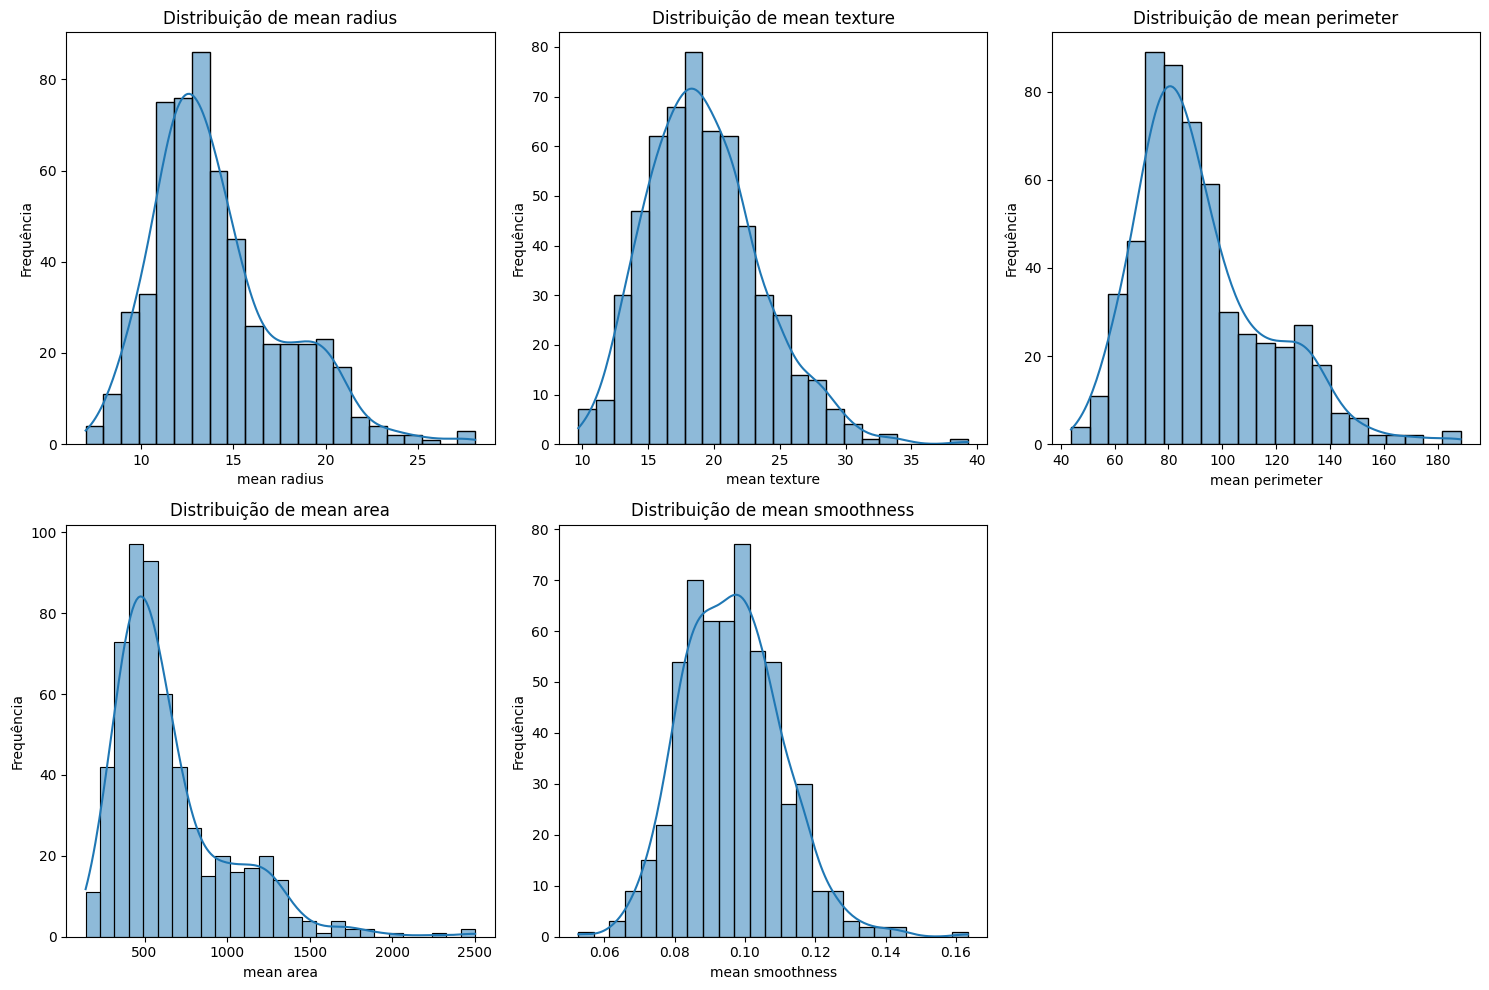

In [16]:
# Selecionar algumas variáveis 'mean' para visualizar a distribuição
mean_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(mean_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data_df[feature], kde=True)
    plt.title(f'Distribuição de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Analise
- Todas são distribuições com aspecto normal, algumas mais assimétricas para direita do que outras
- Todas possuem um pico visível

## Existem correlações importantes entre as variáveis?

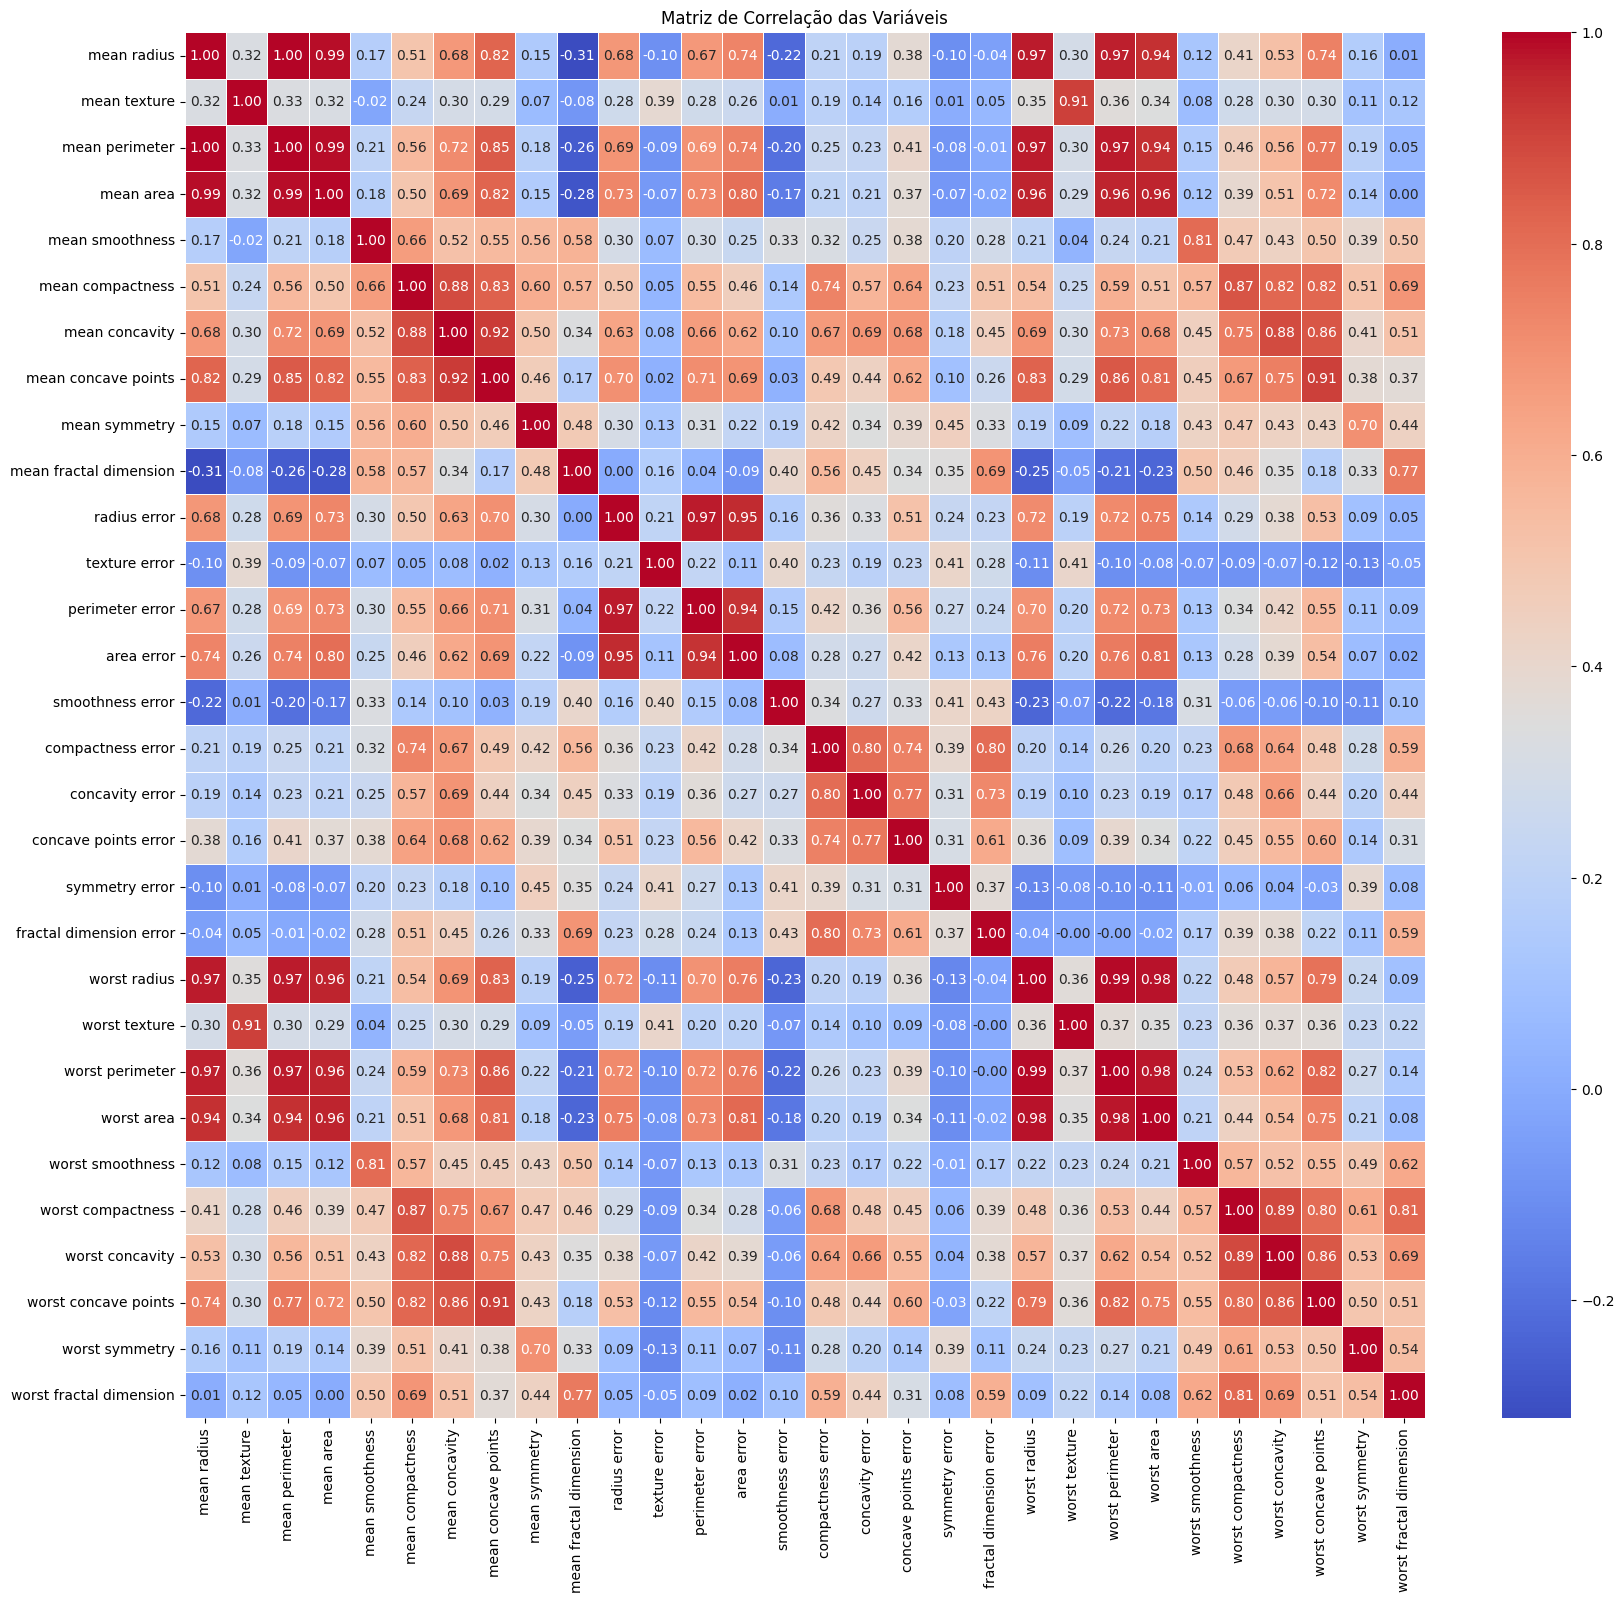

In [17]:
# Correlação com heatmap
correlation_matrix = data_df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

### Análise
- O dataset apresenta muitas variáveis com forte correlação
- As correlações são "separadas em blocos", ou seja, existem grupos específicos de variáveis exibem alta interdependência, com períodos de menor correlação entre eles (muito a ver com a multicolinearidade)
- Foi identificada multicolinearidade entre certas variáveis, indicando uma correlação tão forte que a remoção de uma ou mais delas é recomendada para evitar impactos negativos na análise de regressão
  - ex: mean radius, mean area e mean perimeter "meio que" se referem a "mesma coisa"

OBS: normalmente eu não faço o heatmap de TUDO, mas esse ficou tão lindo que deixei kkkkkk

## Quais insights podem ser extraídos dos dados?

- As colunas presentes na visualização de distribuição apresentam padrão semelhante à distribuição normal, porém com assimetria à direita
- As variáveis 'mean radius', 'mean perimeter' e 'mean area' possum distribuição quase iguais, o que supõe grande correlação entre elas
  - A hipótese é confirmada ao verificar no heatmap de correlação ('mean radius' x 'mean perimeter' = 1.00; 'mean radius' x 'mean area' = 0.99; 'mean perimeter' x 'mean area' = 0.99)
- Quando múltiplas variáveis são fortemente correlacionadas (como no caso acima), opta-se por descatar algumas variáveis em modelos de regressão, devido aos problemas associados à multicolinearidade

## Qual pré-processamento foi necessário e por quê?

Fora a divisão de treino/teste (que é basicamente a base de tudo), o único pré-processamento necessário foi a normalização, por causa da diferença de grandeza entre as colunas

## Distribuição do Y
Como o intuito do Dataset é ver se o tumor é benigno ou maligno, achei interessante mostrar a distribuição entre as categorias e um pouco da relação do resultado (Y) de acordo com as variáveis que verificamos alta correlação

/tmp/ipykernel_1735/641931431.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_names', data=target_df, palette='viridis')


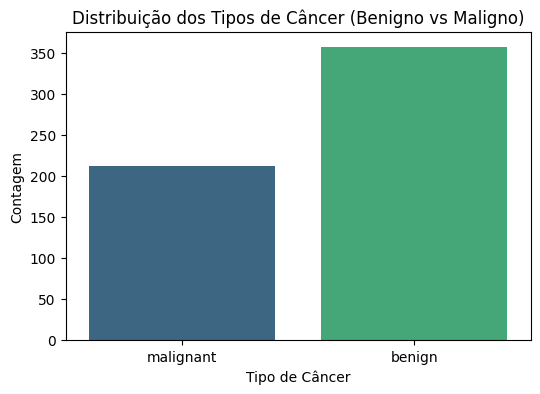

In [23]:
# Para plotar a distribuição da variável alvo, precisamos convertê-la para um DataFrame
target_df = pd.DataFrame(data.target, columns=['target'])
target_df['target_names'] = target_df['target'].map(lambda x: data.target_names[x])

plt.figure(figsize=(6, 4))
sns.countplot(x='target_names', data=target_df, palette='viridis')
plt.title('Distribuição dos Tipos de Câncer (Benigno vs Maligno)')
plt.xlabel('Tipo de Câncer')
plt.ylabel('Contagem')
plt.show()

/tmp/ipykernel_1735/2580311915.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_names', y=feature, data=df_with_target, palette='coolwarm')
/tmp/ipykernel_1735/2580311915.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_names', y=feature, data=df_with_target, palette='coolwarm')
/tmp/ipykernel_1735/2580311915.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_names', y=feature, data=df_with_target, palette='coolwarm')
/tmp/ipykernel_1735/2580311915.py:10: FutureWarning: 

Passing `palette` without assi

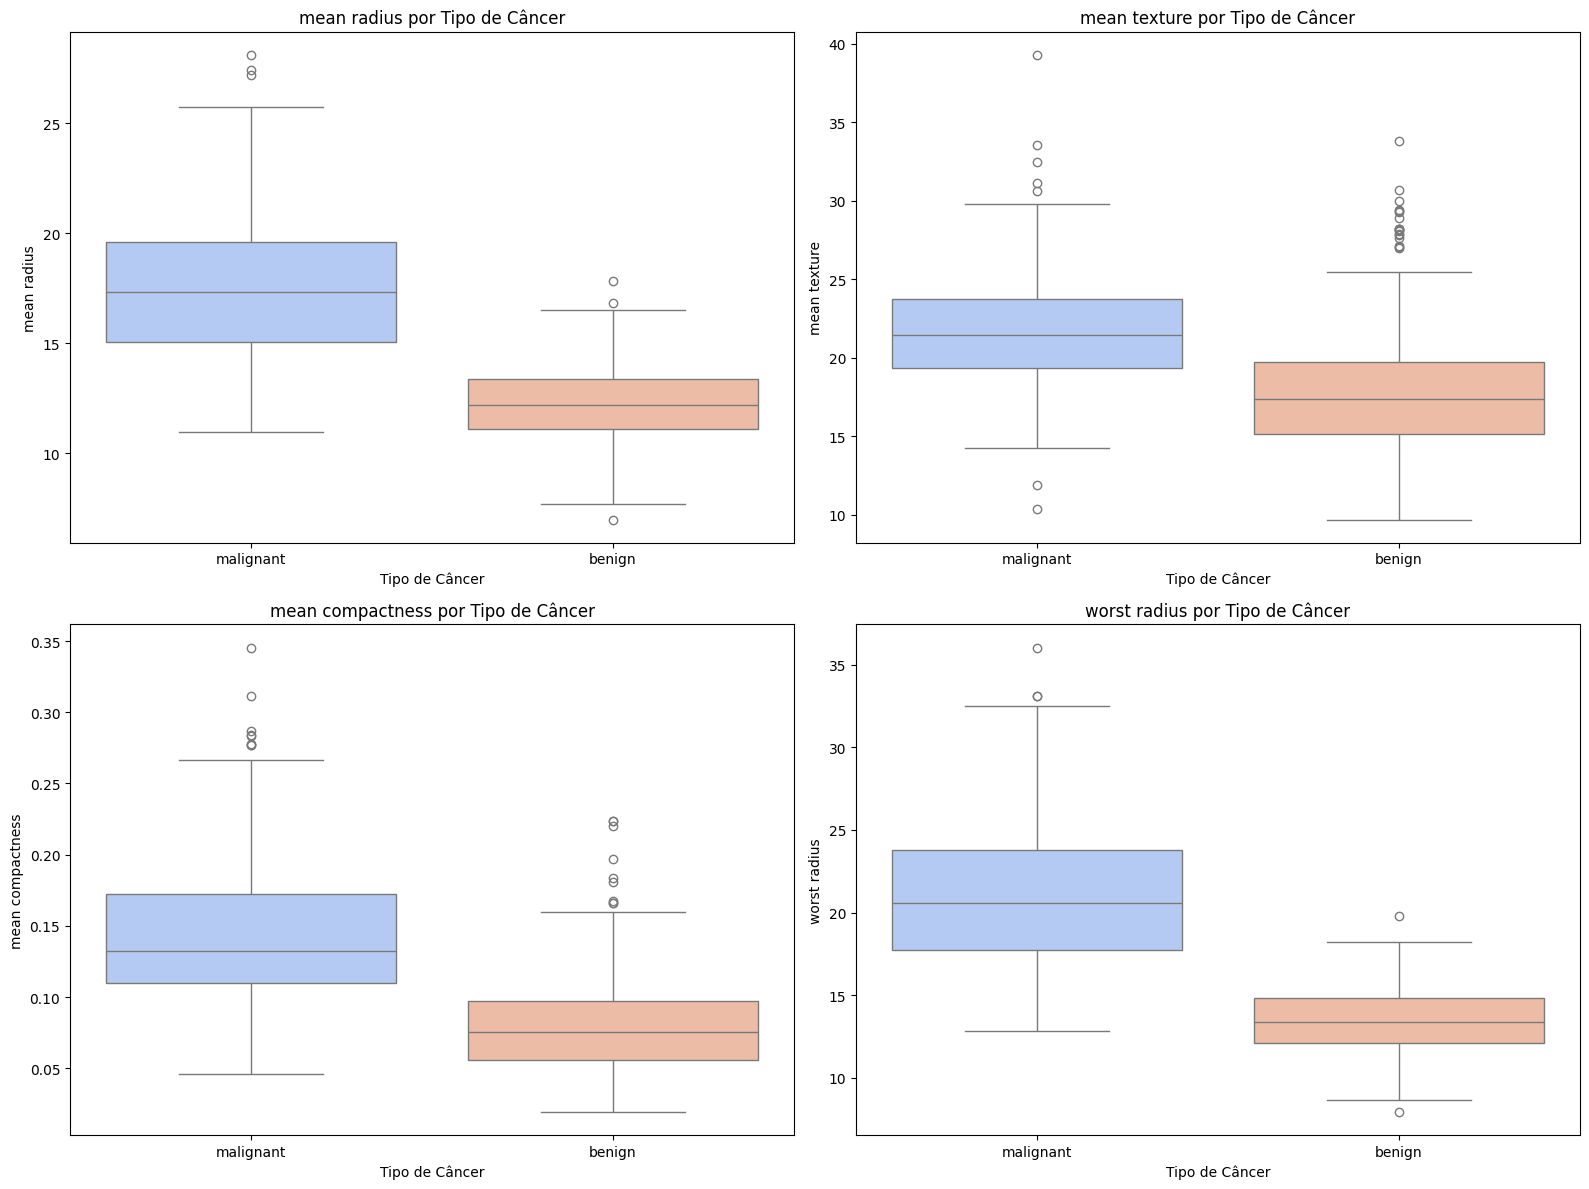

In [24]:
df_with_target = data_df.copy()
df_with_target['target'] = data.target
df_with_target['target_names'] = df_with_target['target'].map(lambda x: data.target_names[x])

# worst radius x mean radius = 0.97
selected_features_for_boxplot = ['mean radius', 'mean texture', 'mean compactness', 'worst radius']

plt.figure(figsize=(16, 12))
for i, feature in enumerate(selected_features_for_boxplot):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='target_names', y=feature, data=df_with_target, palette='coolwarm')
    plt.title(f'{feature} por Tipo de Câncer')
    plt.xlabel('Tipo de Câncer')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Análise
- Percebemos que a maioria dos tumores no dataset são benignos
- Há uma forte diferença entre a distribuições das variáveis de acordo com a categoria do tumor
  - Benigno se caracteriza por mean radius, mean texture, mean compacteness e worst radius menores. Enquanto o maligno possui valores maiores para as variáveis
